🚀 Fixing CycleGAN...
Content: /content/Assignment6/pexels-molnartamasphotography-29202983.jpg
Style: None
Input prepared: /content/Assignment6/cyclegan_input/landscape.jpg

🎨 Running CycleGAN → Monet...
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: /content/Assignment6/cyclegan_input	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3          

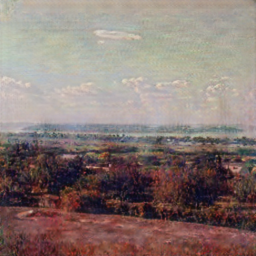

In [ ]:


import os
import sys
import shutil
import subprocess
from pathlib import Path
from PIL import Image

BASE = Path("/content/Assignment6")
REPO = BASE / "pytorch-CycleGAN-and-pix2pix"
OUTPUT = BASE / "outputs"
cyclegan_input = BASE / "cyclegan_input"
cyclegan_results = BASE / "cyclegan_results"

OUTPUT.mkdir(exist_ok=True)
cyclegan_input.mkdir(exist_ok=True)

print("🚀 Fixing CycleGAN...")

# ------------------------------------------------------------
# Find uploaded content image
# ------------------------------------------------------------
images = [
    f for f in BASE.iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
]

style_words = ["van", "vangogh", "starry"]

style_file = None
content_file = None

for f in images:
    if any(word in f.name.lower() for word in style_words):
        style_file = f
    else:
        content_file = f

print("Content:", content_file)
print("Style:", style_file)

# ------------------------------------------------------------
# Prepare CycleGAN input
# ------------------------------------------------------------
cycle_input = cyclegan_input / "landscape.jpg"

shutil.copy(content_file, cycle_input)

print("Input prepared:", cycle_input)

# ------------------------------------------------------------
# Run CycleGAN
# IMPORTANT: NO --gpu_ids argument
# ------------------------------------------------------------
print("\n🎨 Running CycleGAN → Monet...")

cmd = [
    sys.executable,
    "test.py",
    "--dataroot", str(cyclegan_input),
    "--name", "style_monet_pretrained",
    "--model", "test",
    "--no_dropout",
    "--preprocess", "resize",
    "--load_size", "256",
    "--results_dir", str(cyclegan_results),
    "--num_test", "1"
]

result = subprocess.run(
    cmd,
    cwd=str(REPO),
    capture_output=True,
    text=True
)

print(result.stdout[-5000:])

if result.returncode != 0:
    print("\n❌ ERROR:")
    print(result.stderr[-5000:])
    raise RuntimeError("CycleGAN failed")

# ------------------------------------------------------------
# Find CycleGAN output
# ------------------------------------------------------------
cycle_images = list(cyclegan_results.rglob("*fake*.png"))

if not cycle_images:
    cycle_images = list(cyclegan_results.rglob("*.png"))

print("\nGenerated images:")
for img in cycle_images:
    print(img)

if not cycle_images:
    raise FileNotFoundError("CycleGAN output was not found.")

cycle_output = cycle_images[0]

final_cycle = OUTPUT / "cyclegan_monet.png"
shutil.copy(cycle_output, final_cycle)

print("\n✅ CycleGAN completed!")
print("Output:", final_cycle)

# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------
display(Image.open(final_cycle))

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "GPU NOT ENABLED")

False
GPU NOT ENABLED


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: False


In [ ]:
from google.colab import files
from pathlib import Path
import shutil

BASE = Path("/content/Assignment6")
BASE.mkdir(exist_ok=True)

print("📤 Select your Van Gogh Starry Night image")
uploaded = files.upload()

for filename in uploaded.keys():
    shutil.copy(filename, BASE / filename)
    print("✅ Uploaded:", filename)

print("\nImages now available:")
for f in BASE.iterdir():
    if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]:
        print(" -", f.name)

📤 Select your Van Gogh Starry Night image


Saving Van_Gogh_-_Starry_Night_-_Google_Art_Project (1).jpg to Van_Gogh_-_Starry_Night_-_Google_Art_Project (1) (2).jpg
✅ Uploaded: Van_Gogh_-_Starry_Night_-_Google_Art_Project (1) (2).jpg

Images now available:
 - Landscape_Jpg_(163084131).jpeg
 - pexels-molnartamasphotography-29202983.jpg
 - Van_Gogh_-_Starry_Night_-_Google_Art_Project (1) (1).jpg
 - Van_Gogh_-_Starry_Night_-_Google_Art_Project (1).jpg
 - pexels-molnartamasphotography-29202983 (1).jpg
 - Van_Gogh_-_Starry_Night_-_Google_Art_Project (1) (2).jpg


Using: cpu
Content: Landscape_Jpg_(163084131).jpeg
Style: Van_Gogh_-_Starry_Night_-_Google_Art_Project (1) (1).jpg

Loading VGG19...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 64.5MB/s]


VGG19 loaded!

Extracting features...

Starting Starry Night style transfer...
Step 10/100
Step 20/100
Step 30/100
Step 40/100
Step 50/100
Step 60/100
Step 70/100
Step 80/100
Step 90/100
Step 100/100

✅ Starry Night NST completed!
/content/Assignment6/outputs/nst_starry_night.png


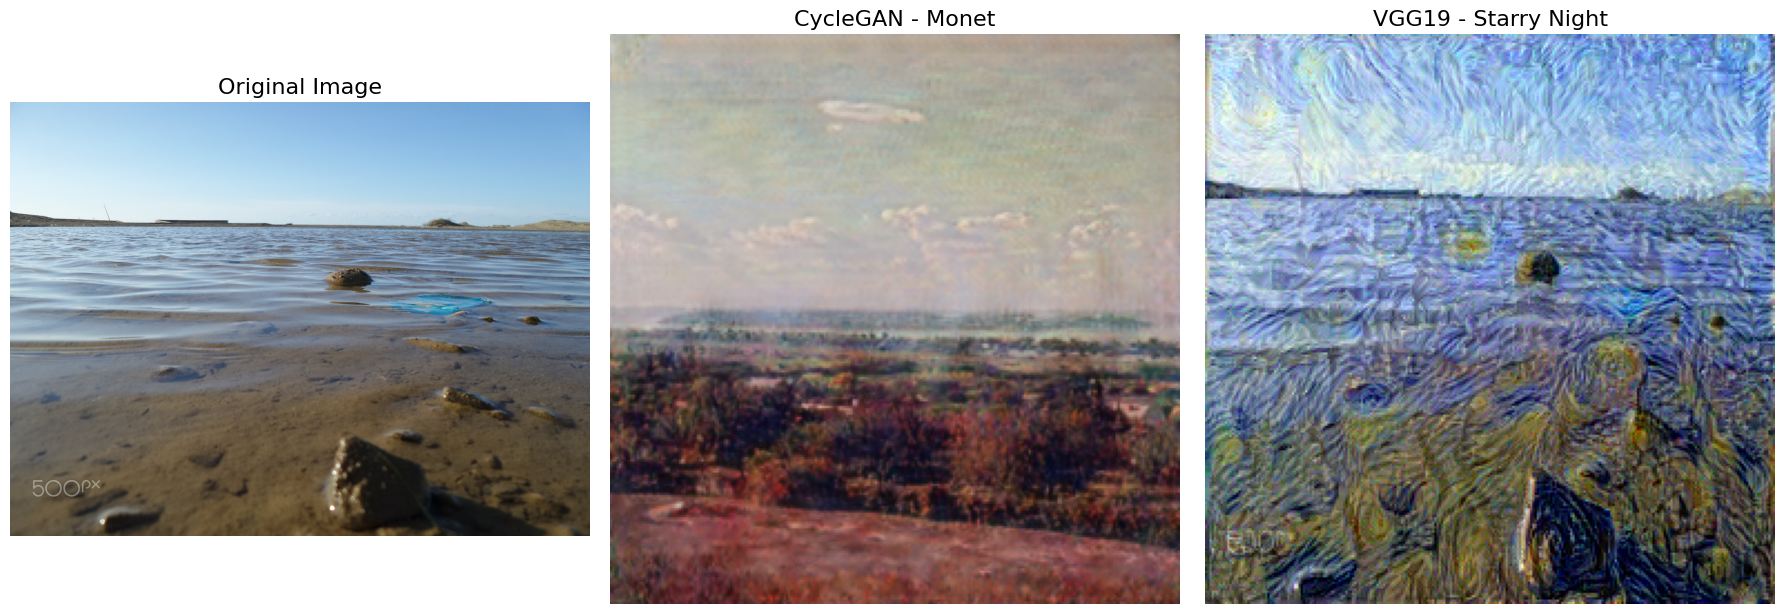


🎉 ASSIGNMENT 6 COMPLETE!
Final comparison: /content/Assignment6/outputs/comparison.png


In [ ]:
# VGG19 Neural Style Transfer - CPU version

import torch
import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights
from PIL import Image
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("/content/Assignment6")
OUTPUT = BASE / "outputs"
OUTPUT.mkdir(exist_ok=True)

device = torch.device("cpu")
print("Using:", device)

# -------------------------------------------------
# Explicitly select your files
# -------------------------------------------------
content_file = BASE / "Landscape_Jpg_(163084131).jpeg"

style_file = BASE / "Van_Gogh_-_Starry_Night_-_Google_Art_Project (1) (1).jpg"

# If that exact duplicate doesn't exist, find the Starry Night file
if not style_file.exists():
    starry_files = [
        f for f in BASE.iterdir()
        if "Van_Gogh" in f.name and f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    if not starry_files:
        raise FileNotFoundError("Starry Night image not found.")

    style_file = starry_files[0]

print("Content:", content_file.name)
print("Style:", style_file.name)

# -------------------------------------------------
# Load images
# -------------------------------------------------
SIZE = 256

transform = transforms.Compose([
    transforms.Resize((SIZE, SIZE)),
    transforms.ToTensor()
])

def load_image(path):
    return transform(
        Image.open(path).convert("RGB")
    ).unsqueeze(0).to(device)

content = load_image(content_file)
style = load_image(style_file)

# -------------------------------------------------
# VGG19
# -------------------------------------------------
print("\nLoading VGG19...")

model = vgg19(
    weights=VGG19_Weights.DEFAULT
).features.to(device).eval()

for p in model.parameters():
    p.requires_grad = False

print("VGG19 loaded!")

# -------------------------------------------------
# Normalize
# -------------------------------------------------
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(1, 3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(1, 3, 1, 1)

def normalize(x):
    return (x - mean) / std

# -------------------------------------------------
# Gram matrix
# -------------------------------------------------
def gram_matrix(x):
    b, c, h, w = x.shape
    features = x.view(c, h*w)
    gram = torch.mm(features, features.t())
    return gram / (c*h*w)

# -------------------------------------------------
# Layers
# -------------------------------------------------
style_layers = ["0", "5", "10", "19", "28"]
content_layer = "21"

def get_features(image):

    features = {}
    x = normalize(image)

    for name, layer in model._modules.items():

        x = layer(x)

        if name in style_layers or name == content_layer:
            features[name] = x

    return features

print("\nExtracting features...")

content_features = get_features(content)
style_features = get_features(style)

style_grams = {
    layer: gram_matrix(style_features[layer])
    for layer in style_layers
}

# -------------------------------------------------
# Optimization
# -------------------------------------------------
generated = content.clone().requires_grad_(True)

optimizer = optim.Adam(
    [generated],
    lr=0.03
)

STEPS = 100

print("\nStarting Starry Night style transfer...")

for step in range(STEPS):

    generated_features = get_features(generated)

    content_loss = torch.mean(
        (
            generated_features[content_layer]
            - content_features[content_layer]
        ) ** 2
    )

    style_loss = 0

    for layer in style_layers:

        generated_gram = gram_matrix(
            generated_features[layer]
        )

        style_loss += torch.mean(
            (
                generated_gram
                - style_grams[layer]
            ) ** 2
        )

    loss = content_loss + 1e6 * style_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        generated.clamp_(0, 1)

    if (step + 1) % 10 == 0:
        print(f"Step {step+1}/{STEPS}")

# -------------------------------------------------
# Save NST result
# -------------------------------------------------
nst_path = OUTPUT / "nst_starry_night.png"

result = generated.detach().cpu().squeeze(0)
result = transforms.ToPILImage()(result)
result.save(nst_path)

print("\n✅ Starry Night NST completed!")
print(nst_path)

# -------------------------------------------------
# Original + CycleGAN + NST
# -------------------------------------------------
original = Image.open(content_file).convert("RGB")
cycle = Image.open(OUTPUT / "cyclegan_monet.png")
nst = Image.open(nst_path)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

axes[0].imshow(original)
axes[0].set_title("Original Image", fontsize=16)
axes[0].axis("off")

axes[1].imshow(cycle)
axes[1].set_title("CycleGAN - Monet", fontsize=16)
axes[1].axis("off")

axes[2].imshow(nst)
axes[2].set_title("VGG19 - Starry Night", fontsize=16)
axes[2].axis("off")

plt.tight_layout()

comparison = OUTPUT / "comparison.png"

plt.savefig(
    comparison,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\n🎉 ASSIGNMENT 6 COMPLETE!")
print("Final comparison:", comparison)